In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import math

In [3]:
df = pd.read_csv("AF_MFU_4l_first_Co_exchange.txt", sep = ' ')

In [4]:
print(df)
print(df.shape)

       2.00000  4776.000
0      2.01947    4694.0
1      2.03893    4587.0
2      2.05840    4537.0
3      2.07787    4279.0
4      2.09734    4317.0
...        ...       ...
1947  39.92172     495.0
1948  39.94118     530.0
1949  39.96065     462.0
1950  39.98012     477.0
1951  39.99958     467.0

[1952 rows x 2 columns]
(1952, 2)


In [5]:
# x = df['2.00000'] # this works, but i would like to make these data points and rename each column as what they are (i.e. 2theta = x and intensity = y)
# y = df['4776.000']

# # print(x)
# #print(y)

# plt.plot(x, y, label = 'data')
# plt.show()

In [6]:
new_row = pd.DataFrame([[2.00000, 4776.00]], columns=df.columns) # adds a column w/ the same values that were automatically made the column names

df = pd.concat([new_row, df], ignore_index=True)
print(df)

       2.00000  4776.000
0      2.00000    4776.0
1      2.01947    4694.0
2      2.03893    4587.0
3      2.05840    4537.0
4      2.07787    4279.0
...        ...       ...
1948  39.92172     495.0
1949  39.94118     530.0
1950  39.96065     462.0
1951  39.98012     477.0
1952  39.99958     467.0

[1953 rows x 2 columns]


In [7]:
df.columns = ["2-Theta (degrees)", "Intensity (counts)"] # changed the column names to actual names!!
print(df)

      2-Theta (degrees)  Intensity (counts)
0               2.00000              4776.0
1               2.01947              4694.0
2               2.03893              4587.0
3               2.05840              4537.0
4               2.07787              4279.0
...                 ...                 ...
1948           39.92172               495.0
1949           39.94118               530.0
1950           39.96065               462.0
1951           39.98012               477.0
1952           39.99958               467.0

[1953 rows x 2 columns]


In [8]:
x = df["2-Theta (degrees)"].astype(float) # MUST MAKE DATA FLOATS! they're objects otherwise and matplotlib no likey...
y = df["Intensity (counts)"].astype(float)

print(x)
print(y)

0        2.00000
1        2.01947
2        2.03893
3        2.05840
4        2.07787
          ...   
1948    39.92172
1949    39.94118
1950    39.96065
1951    39.98012
1952    39.99958
Name: 2-Theta (degrees), Length: 1953, dtype: float64
0       4776.0
1       4694.0
2       4587.0
3       4537.0
4       4279.0
         ...  
1948     495.0
1949     530.0
1950     462.0
1951     477.0
1952     467.0
Name: Intensity (counts), Length: 1953, dtype: float64


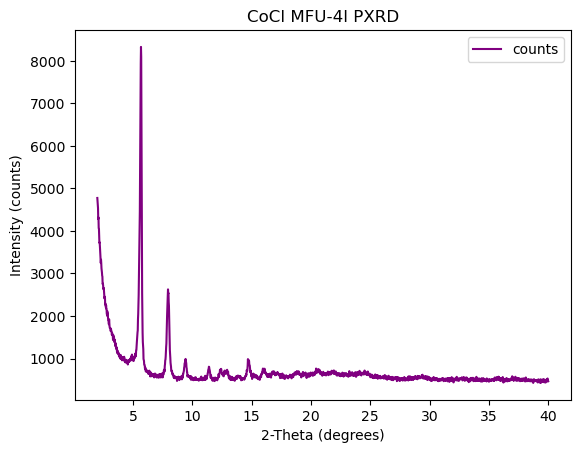

In [9]:
plt.figure()
plt.plot(x, y, label = 'counts', color = 'purple')
plt.xlabel("2-Theta (degrees)")
plt.ylabel("Intensity (counts)")
plt.title("CoCl MFU-4l PXRD")
plt.legend()
plt.show()

In [10]:
# now to try and curve fit...! i will only try to fit the peaks @ ~5, ~7, ~9, and ~15.
# i found online that all XRD data is a combination of gaussians, lorentzians, and voigt functions. i will start with gaussian curve fitting.

# p0 = [5.5, 6.6, 900]

# def f(x, amp, mu, sigma):
#     return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# popt, pcov = curve_fit(f, x, y, p0 = p0)
# A_fit = popt[0]
# residuals = y - f(x, A_fit, m, s)
# chi2 = np.sum(residuals**2)
# dof = len(x) - len(popt)
# chi2_reduced = chi2 / dof
# print(chi2_reduced)

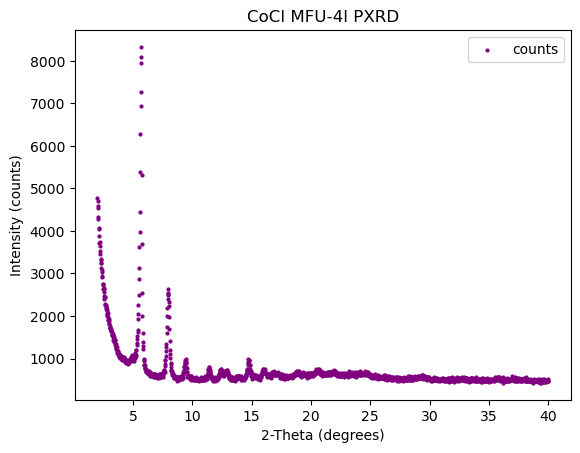

In [11]:
plt.figure()
plt.scatter(x, y, label = 'counts', color = 'purple', s=4)
#plt.plot(x, f(x, *popt), color = 'red')
plt.xlabel("2-Theta (degrees)")
plt.ylabel("Intensity (counts)")
plt.title("CoCl MFU-4l PXRD")
plt.legend()
plt.show()

In [12]:
# def multi_gaussian(x, amp1, mu1, sigma1, amp2, mu2, sigma2, amp3, mu3, sigma3):
#     g1 = gaussian(x, amp1, mu1, sigma1)
#     g2 = gaussian(x, amp2, mu2, sigma2)
#     g3 = gaussian(x, amp3, mu3, sigma3)
#     return g1 + g2 + g3


In [13]:
slice = (x > 4) & (x < 17)
#print(slice)

df_sl = df.loc[slice, :]

x_sl = df_sl['2-Theta (degrees)']
y_sl = df_sl['Intensity (counts)']

print(x_sl)
print(y_sl)

103     4.00510
104     4.02457
105     4.04404
106     4.06350
107     4.08297
         ...   
766    16.91172
767    16.93119
768    16.95066
769    16.97012
770    16.98959
Name: 2-Theta (degrees), Length: 668, dtype: float64
103    1030.0
104    1045.0
105     994.0
106    1030.0
107     958.0
        ...  
766     654.0
767     681.0
768     622.0
769     632.0
770     606.0
Name: Intensity (counts), Length: 668, dtype: float64


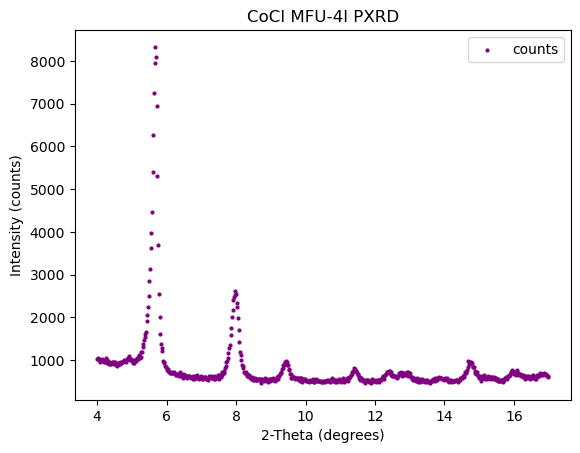

In [14]:
plt.figure()
plt.scatter(x_sl, y_sl, label = 'counts', color = 'purple', s=4) 
plt.xlabel("2-Theta (degrees)")
plt.ylabel("Intensity (counts)")
plt.title("CoCl MFU-4l PXRD")
plt.legend()
plt.show() # sliced data set to (hopefully) match the most important peaks of my data set

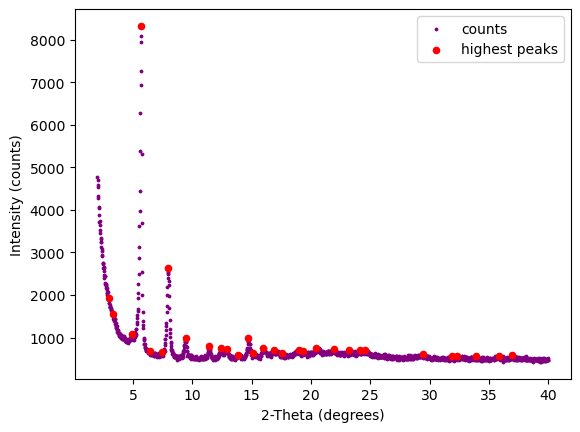

In [15]:
peaks, _ = find_peaks(y, prominence=100)
peaks = peaks[np.argsort(y[peaks])[::-1]]  # sort by height

plt.figure()
plt.scatter(x, y, label="counts", color = "purple", s=3)

plt.scatter(x[peaks], y[peaks], color="red", label="highest peaks", s=20)

plt.xlabel("2-Theta (degrees)")
plt.ylabel("Intensity (counts)")
plt.legend()
plt.show()

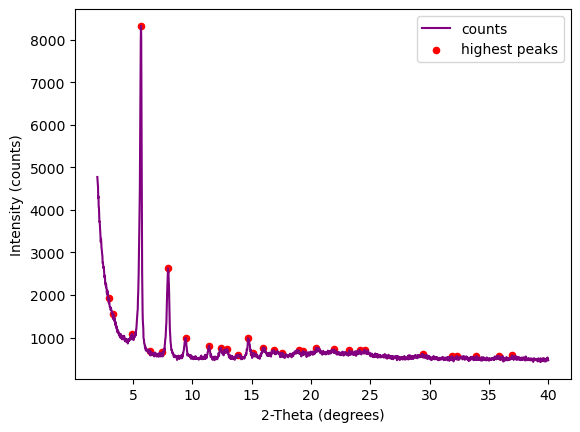

In [16]:
plt.figure()
plt.plot(x, y, label="counts", color = "purple")

plt.scatter(x[peaks], y[peaks], color="red", label="highest peaks", s=20)

plt.xlabel("2-Theta (degrees)")
plt.ylabel("Intensity (counts)")
plt.legend()
plt.show()

In [17]:
for p in peaks:
    print(f"Peak at x =", x[p], "with intensity =", y[p]) # with this information, i will first write a multi_gaussian that fits the tallest peaks only.

Peak at x = 5.67926 with intensity = 8328.0
Peak at x = 7.9569 with intensity = 2626.0
Peak at x = 2.99282 with intensity = 1922.0
Peak at x = 3.34322 with intensity = 1553.0
Peak at x = 4.92005 with intensity = 1092.0
Peak at x = 9.43639 with intensity = 990.0
Peak at x = 14.69248 with intensity = 986.0
Peak at x = 11.40256 with intensity = 807.0
Peak at x = 15.95784 with intensity = 765.0
Peak at x = 20.43525 with intensity = 764.0
Peak at x = 12.43431 with intensity = 757.0
Peak at x = 12.94045 with intensity = 735.0
Peak at x = 21.93421 with intensity = 720.0
Peak at x = 24.52332 with intensity = 717.0
Peak at x = 24.09505 with intensity = 710.0
Peak at x = 23.2385 with intensity = 703.0
Peak at x = 16.87279 with intensity = 701.0
Peak at x = 18.95576 with intensity = 698.0
Peak at x = 19.32563 with intensity = 683.0
Peak at x = 6.47741 with intensity = 682.0
Peak at x = 7.48969 with intensity = 657.0
Peak at x = 17.59307 with intensity = 647.0
Peak at x = 15.14023 with intensity =

In [18]:
print(y[peaks].iloc[1])
print(x[peaks].iloc[1])

2626.0
7.9569


In [19]:
# def f(x, amp, mu, sigma):
#     return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# def multi_f(x, amp1, mu1, sigma1, amp2, mu2, sigma2, amp3, mu3, sigma3, amp4, mu4, sigma4, amp5, mu5, sigma5):
#     f1 = f(x, amp1, mu1, sigma1)
#     f2 = f(x, amp2, mu2, sigma2)
#     f3 = f(x, amp3, mu3, sigma3)
#     f4 = f(x, amp4, mu4, sigma4)
#     f5 = f(x, amp5, mu5, sigma5)
#     f6 = f(x, amp6, mu6, sigma6)

In [20]:
# this block of code currently gives me a graph that very nicely matches my first peak, but nothing else.

A_guess = np.asarray(y[peaks], dtype=float)
mu_guess = np.asarray(x[peaks], dtype=float)
sigma_guess = np.full(len(peaks), (max(x) - min(x) / 150)) # np.full() makes an array with a specific value that matches the shape of an existing array! fixes the error i'm having with sigma_guess[index] not working

p0 = [
    A_guess[0], mu_guess[0], sigma_guess[0],
    A_guess[8], mu_guess[8], sigma_guess[8],
    A_guess[12], mu_guess[12], sigma_guess[12],
    A_guess[15], mu_guess[15], sigma_guess[15],
    A_guess[21], mu_guess[21], sigma_guess[21],
    A_guess[26], mu_guess[26], sigma_guess[26]
]

def f(x, *params):
    y = np.zeros_like(x)
    for i in range(0, len(params), 3):
        amp = params[i]
        mu = params[i+1]
        sigma = params[i+2]
        y += amp * np.exp(-0.5 * ((x - mu) / sigma)**2)  
        # print(type(mu))
        # print(type(x))
    return y
    
popt, pcov = curve_fit(f, x, y, p0 = p0, maxfev = 100000)

A_fit = popt[0::3]
mu_fit = popt[1::3]
sigma_fit = popt[2::3]

residuals = y - f(x, *popt)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
print(chi2_reduced)

27158.067655188734


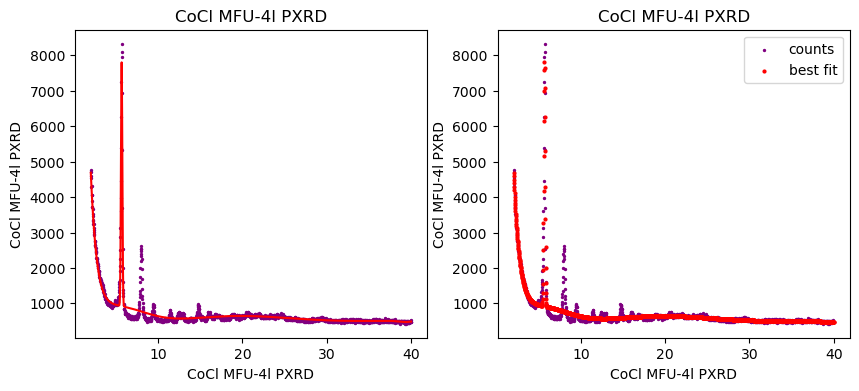

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].scatter(x, y, label = 'counts', color = 'purple', s=2) # same as plt.plot, but we specify axes information to say which plot is which (i.e. [0] is leftmost, [1] is rightmost in this scenario)
axes[0].plot(x, f(x, *popt), label = 'best fit', color = 'red')
axes[0].set_title("CoCl MFU-4l PXRD")
axes[0].set_xlabel("CoCl MFU-4l PXRD")
axes[0].set_ylabel("CoCl MFU-4l PXRD")

axes[1].scatter(x, y, label = 'counts', color = 'purple', s=2)
axes[1].scatter(x, f(x, *popt), label = 'best fit', color = 'red', s=4)
axes[1].set_title("CoCl MFU-4l PXRD")
axes[1].set_xlabel("CoCl MFU-4l PXRD")
axes[1].set_ylabel("CoCl MFU-4l PXRD")

plt.legend()
plt.show()

# plt.scatter(x, y, label = 'counts', color = 'purple', s=2)
# axes.scatter(x, f(x, *popt), color = 'red', s=4)
# plt.xlabel("2-Theta (degrees)")
# plt.ylabel("Intensity (counts)")
# plt.title("CoCl MFU-4l PXRD")
# plt.legend()
# plt.show()

# omg it actually matches the first peak very well!!  however. none of the rest of the data is matched ...

In [22]:
A_guess = np.asarray(y[peaks], dtype=float)
mu_guess = np.asarray(x[peaks], dtype=float)
sigma_guess = np.full(len(peaks), (max(x) - min(x)) / 150) # np.full() makes an array with a specific value that matches the shape of an existing array! fixes the error i'm having with sigma_guess[index] not working

p0 = [
    A_guess[0], mu_guess[0], sigma_guess[0],
    A_guess[1], mu_guess[1], sigma_guess[1],
    A_guess[2], mu_guess[2], sigma_guess[2],
    A_guess[3], mu_guess[3], sigma_guess[3],
    A_guess[4], mu_guess[4], sigma_guess[4],
    A_guess[5], mu_guess[5], sigma_guess[5],
    A_guess[6], mu_guess[6], sigma_guess[6],
    A_guess[7], mu_guess[7], sigma_guess[7],
    A_guess[8], mu_guess[8], sigma_guess[8]
]

# lower = [0, 0, 0.05] * 3
# upper = [np.inf, 40, 0.5] * 3


def f(x, *params):
    y = np.zeros_like(x)
    for i in range(0, len(params), 3):
        amp = params[i]
        mu = params[i+1]
        sigma = params[i+2]
        y += amp * np.exp(-0.5 * ((x - mu) / sigma)**2)  
        # print(type(mu))
        # print(type(x))
    return y
    
popt, pcov = curve_fit(f, x, y, p0 = p0, maxfev = 100000)

A_fit = popt[0::3]
mu_fit = popt[1::3]
sigma_fit = popt[2::3]

residuals = y - f(x, *popt)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
print(chi2_reduced)

2972.2631753456267


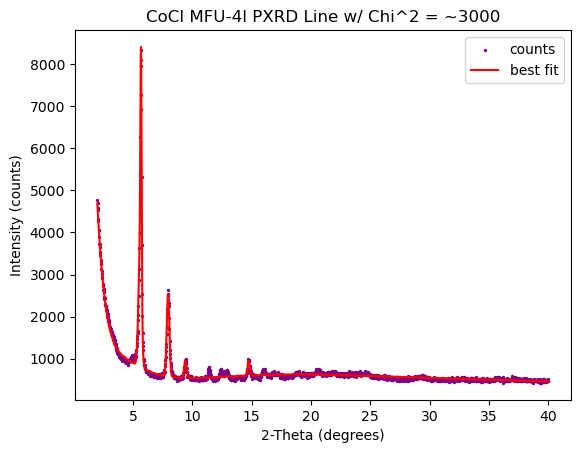

In [25]:
plt.figure()
plt.scatter(x, y, label = 'counts', color = 'purple', s=2)
plt.plot(x, f(x, *popt), label = 'best fit', color = 'red')
plt.xlabel("2-Theta (degrees)")
plt.ylabel("Intensity (counts)")
plt.title("CoCl MFU-4l PXRD Line w/ Chi^2 = ~3000")
plt.legend()
plt.show()

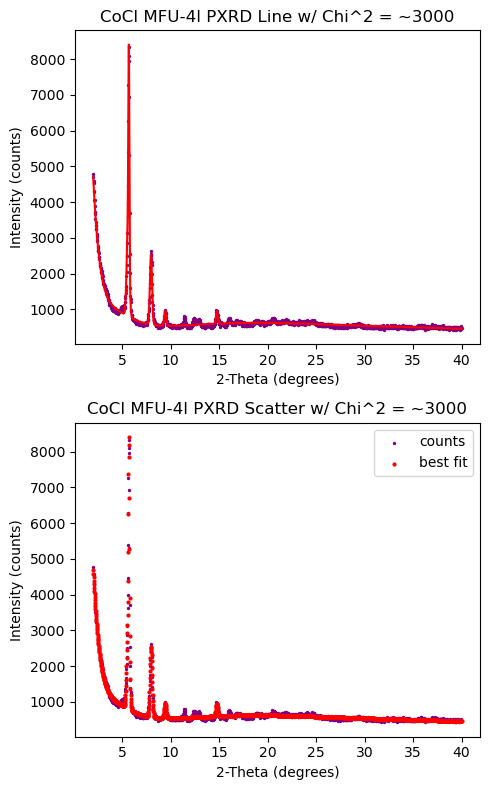

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(5,8))

axes[0].scatter(x, y, label = 'counts', color = 'purple', s=2) # same as plt.plot, but we specify axes information to say which plot is which (i.e. [0] is leftmost, [1] is rightmost in this scenario)
axes[0].plot(x, f(x, *popt), label = 'best fit', color = 'red')
axes[0].set_title("CoCl MFU-4l PXRD Line w/ Chi^2 = ~3000")
axes[0].set_xlabel("2-Theta (degrees)")
axes[0].set_ylabel("Intensity (counts)")

axes[1].scatter(x, y, label = 'counts', color = 'purple', s=2)
axes[1].scatter(x, f(x, *popt), label = 'best fit', color = 'red', s=4)
axes[1].set_title("CoCl MFU-4l PXRD Scatter w/ Chi^2 = ~3000")
axes[1].set_xlabel("2-Theta (degrees)")
axes[1].set_ylabel("Intensity (counts)")

plt.tight_layout()
plt.legend()
plt.show()